# Training with Cleaned Dataset and EDL Type 2
A notebook for training an EfficientNet B3 model with Evidential Deep Learning (EDL Type 2) on a 5-class diabetic retinopathy dataset.
Dataset: `cleaned_dataset` with `train`, `val`, and `test` splits and 0-4 class folders.

## Execution Flow (Correct Order)
### Fast baseline path
1. Run Cells 1-6
2. In Cell 7 set `RUN_SINGLE_BASELINE = True` and run Cell 7
3. Run Cell 8 for single-model test metrics
4. Run Cell 9 to download single checkpoint

### Best-performance path (recommended)
1. Run Cells 1-6
2. Skip Cell 7 (keep baseline off)
3. In Cell 10 set `RUN_KFOLD = True` and run Cell 10
4. In Cell 11 set `USE_ENSEMBLE = True` and run Cell 11
5. Run Cell 9 to download all fold checkpoints as zip

## 1. Import Core Libraries

In [37]:
!pip install torch torchvision timm efficientnet-pytorch scikit-learn pandas matplotlib seaborn opencv-python

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

## 2. Define Hyperparameters and Device Configuration

In [38]:
import kagglehub

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
NUM_EPOCHS = 60
NUM_CLASSES = 5
PATIENCE = 15

# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download('dondirecto/dr-training')
print(f"Dataset path: {dataset_path}")

# Set base paths to point to the local workspace folder
BASE_DIR = os.path.join(dataset_path, 'cleaned_dataset')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

Using device: cuda
Using Colab cache for faster access to the 'dr-training' dataset.
Dataset path: /kaggle/input/dr-training


## 3. Configure Data Transforms and Loaders

In [39]:
from torch.utils.data import WeightedRandomSampler

import cv2
from PIL import Image

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = self.clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_clahe)

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.RandomHorizontalFlip(),
        # Vertical flip can create unrealistic retina orientation; keep geometric jitter mild.
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.97, 1.03)),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val_test']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['val_test'])
}

train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

# Sampler weights for balancing minibatches
sampler_class_weights = 1.0 / torch.tensor(np.clip(class_counts, 1, None), dtype=torch.float)
sample_weights = sampler_class_weights[train_targets]

# Loss weights for stronger minority-class learning (mean-normalized for stable scale)
class_weights_for_loss = torch.tensor(
    class_counts.sum() / (NUM_CLASSES * np.clip(class_counts, 1, None)),
    dtype=torch.float,
    device=device
 )
class_weights_for_loss = class_weights_for_loss / class_weights_for_loss.mean()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Original Class Counts in Train: {class_counts}")
print(f"Sampler Class Weights: {sampler_class_weights}")
print(f"Loss Class Weights (normalized): {class_weights_for_loss}")
print(f"Total Dataset Sizes: {dataset_sizes}")

Classes: ['0', '1', '2', '3', '4']
Original Class Counts in Train: [6777 3712 2568 1321 1545]
Sampler Class Weights: tensor([0.0001, 0.0003, 0.0004, 0.0008, 0.0006])
Loss Class Weights (normalized): tensor([0.3337, 0.6093, 0.8808, 1.7122, 1.4640], device='cuda:0')
Total Dataset Sizes: {'train': 15923, 'val': 2090, 'test': 2426}


## 4. Define Evidential Deep Learning (Type 2) Loss

In [40]:
# Evidential Deep Learning (EDL) Loss Functions

def relu_evidence(y):
    return torch.nn.functional.relu(y)

def exp_evidence(y):
    return torch.exp(torch.clamp(y, -10, 10))

def softplus_evidence(y):
    return torch.nn.functional.softplus(y)

def kl_divergence(alpha, num_classes, device):
    beta = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    S_alpha = torch.sum(alpha, dim=1, keepdim=True)
    S_beta = torch.sum(beta, dim=1, keepdim=True)
    lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=1, keepdim=True)
    lnB_uni = torch.sum(torch.lgamma(beta), dim=1, keepdim=True) - torch.lgamma(S_beta)
    dg0 = torch.digamma(S_alpha)
    dg1 = torch.digamma(alpha)
    kl = torch.sum((alpha - beta) * (dg1 - dg0), dim=1, keepdim=True) + lnB + lnB_uni
    return kl

def edl_type2_loss(
    output,
    target,
    epoch_num,
    num_classes,
    annealing_step,
    device,
    class_weights=None,
    epsilon=0.1,
    ce_weight=0.4,
    kl_scale=0.05
 ):
    """
    Hybrid loss = EDL + weighted label-smoothed CE.
    This improves class discrimination while preserving uncertainty modeling.
    """
    evidence = softplus_evidence(output)
    alpha = evidence + 1
    S = torch.sum(alpha, dim=1, keepdim=True)

    target_one_hot = torch.eye(num_classes, device=device)[target]
    target_smoothed = target_one_hot * (1.0 - epsilon) + (epsilon / num_classes)

    # EDL data-fit term
    err = torch.sum(target_smoothed * (torch.log(S + 1e-8) - torch.log(alpha + 1e-8)), dim=1, keepdim=True)

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32, device=device),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32, device=device),
    )

    alpha_tilde = target_smoothed + (1 - target_smoothed) * alpha
    kl = kl_divergence(alpha_tilde, num_classes, device)
    edl_loss = torch.mean(err + (annealing_coef * kl * kl_scale))

    # Weighted CE term to push per-class separation and recover minority classes
    ce_loss = F.cross_entropy(
        output,
        target,
        weight=class_weights,
        label_smoothing=epsilon
    )

    return (1.0 - ce_weight) * edl_loss + ce_weight * ce_loss

## 5. Initialize EfficientNet B3 Model

In [41]:
class EfficientNetB3EDL(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(EfficientNetB3EDL, self).__init__()
        if pretrained:
            self.base_model = EfficientNet.from_pretrained('efficientnet-b3')
        else:
            self.base_model = EfficientNet.from_name('efficientnet-b3')

        in_features = self.base_model._fc.in_features

        # Stronger head improves class separation for adjacent DR grades.
        self.base_model._fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.35),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

Loaded pretrained weights for efficientnet-b3


## 6. Implement Training and Validation Steps

In [42]:
# Strong single-run baseline (kept for quick checks before full k-fold)
optimizer = optim.AdamW(
    [
        {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
        {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
    ],
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    best_acc = 0.0
    best_f1 = 0.0
    epochs_no_improve = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    print("Freezing base model for initial warm-up...")
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            print("Unfreezing all layers for deep fine-tuning...")
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4  # head
            optimizer.param_groups[1]['lr'] = 5e-5  # backbone

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            if phase not in dataloaders:
                print(f"{phase} dataloader not found. Skipping.")
                continue

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 25, device,
                        class_weights=class_weights_for_loss,
                        epsilon=0.1,
                        ce_weight=0.45,
                        kl_scale=0.03,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_f1'].append(epoch_f1)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}")

            if phase == 'val':
                scheduler.step()
                if epoch_f1 > best_f1:
                    best_f1 = epoch_f1
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_edl2_efficientnet.pth')
                    print(f" -> Best model saved! (Macro-F1: {best_f1:.4f})")
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping triggered after {epochs_no_improve} epochs without improvement')
            break

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Macro-F1: {best_f1:.4f} | Best val Acc: {best_acc:.4f} | Best val Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

## 7. Execute Single-Run Baseline (Optional)
Use this only for a quick check. For best final performance, use Cells 10-11.

In [43]:
# Optional single-run baseline. For final performance, prefer Cells 10-11 (k-fold + ensemble).
RUN_SINGLE_BASELINE = False

if RUN_SINGLE_BASELINE:
    if 'train' in dataloaders and 'val' in dataloaders:
        print("Starting single-run baseline training...")
        model, history = train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS)
    else:
        print("Dataloaders not initialized mapping to physical files. Please review paths.")
else:
    print("Single-run baseline is configured. Set RUN_SINGLE_BASELINE = True if you want to run it.")

Single-run baseline is configured. Set RUN_SINGLE_BASELINE = True if you want to run it.


## 8. Evaluate on Test Dataset and Extract Uncertainty

Testing (TTA): 100%|██████████| 76/76 [00:08<00:00,  9.21it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",


Single-Model Test Accuracy: 0.1171
Single-Model Test Macro-F1: 0.0872
Single-Model Test Weighted-F1: 0.0531

Single-Model Classification Report:
              precision    recall  f1-score   support

           0     0.2169    0.0211    0.0385       852
           1     0.1065    0.6140    0.1814       215
           2     0.0000    0.0000    0.0000       757
           3     0.2105    0.0115    0.0218       348
           4     0.1199    0.5118    0.1943       254

    accuracy                         0.1171      2426
   macro avg     0.1308    0.2317    0.0872      2426
weighted avg     0.1284    0.1171    0.0531      2426



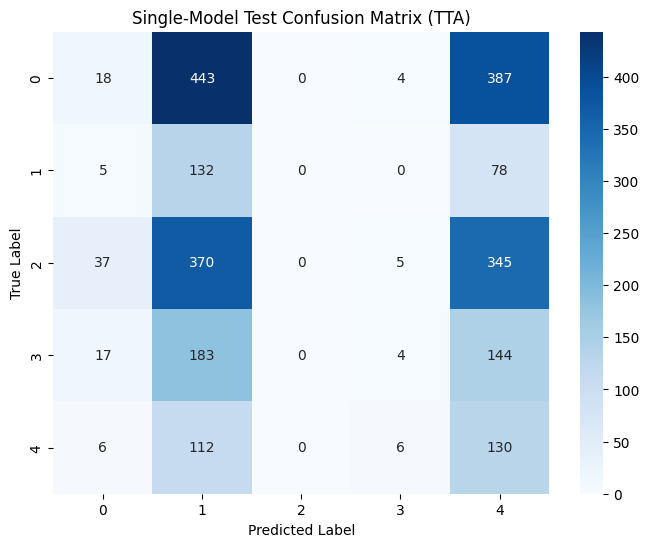

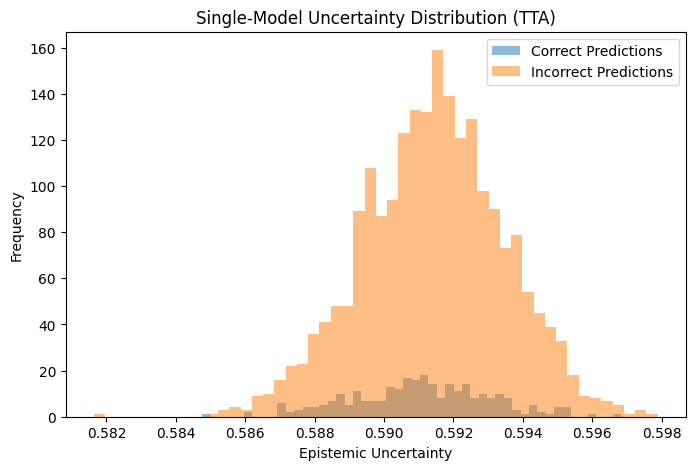

In [44]:
def evaluate_edl_model_tta(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_uncertainties = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Testing (TTA)'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # TTA: original + horizontal flip
            outputs_1 = model(inputs)
            outputs_2 = model(torch.flip(inputs, dims=[3]))

            alpha_1 = softplus_evidence(outputs_1) + 1
            alpha_2 = softplus_evidence(outputs_2) + 1
            alpha = (alpha_1 + alpha_2) / 2.0

            S = torch.sum(alpha, dim=1, keepdim=True)
            u = NUM_CLASSES / S
            _, preds = torch.max(alpha, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(u.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)

if 'test' in dataloaders:
    y_true, y_pred, uncertainties = evaluate_edl_model_tta(model, dataloaders['test'])

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\nSingle-Model Test Accuracy: {acc:.4f}")
    print(f"Single-Model Test Macro-F1: {macro_f1:.4f}")
    print(f"Single-Model Test Weighted-F1: {weighted_f1:.4f}")
    print("\nSingle-Model Classification Report:")
    try:
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    except Exception:
        print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Single-Model Test Confusion Matrix (TTA)')
    plt.show()

    plt.figure(figsize=(8,5))
    plt.hist(uncertainties[y_true == y_pred], bins=50, alpha=0.5, label='Correct Predictions')
    plt.hist(uncertainties[y_true != y_pred], bins=50, alpha=0.5, label='Incorrect Predictions')
    plt.xlabel('Epistemic Uncertainty')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Single-Model Uncertainty Distribution (TTA)')
    plt.show()

## 9. Download Checkpoints (Run After Training)
This cell downloads either:
- `best_edl2_efficientnet.pth` from the single-run baseline, or
- `kfold_checkpoints.zip` when fold checkpoints exist.

In [45]:
import os
import glob
import zipfile

# Download helper for either single best checkpoint or all fold checkpoints
single_ckpt = 'best_edl2_efficientnet.pth'
fold_ckpts = sorted(glob.glob('best_fold_*.pth'))

if len(fold_ckpts) > 0:
    zip_path = 'kfold_checkpoints.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fp in fold_ckpts:
            zf.write(fp)
    model_path = zip_path
    print(f"Prepared archive with fold checkpoints: {fold_ckpts}")
elif os.path.exists(single_ckpt):
    model_path = single_ckpt
    print(f"Prepared single checkpoint: {single_ckpt}")
else:
    model_path = None

if model_path is not None and os.path.exists(model_path):
    try:
        from google.colab import files
        print("Running in Google Colab. Initiating download...")
        files.download(model_path)
    except ImportError:
        from IPython.display import FileLink, display
        print("Not in Colab. Creating a universal download link...")
        display(FileLink(model_path, result_html_prefix="Click here to download: "))
else:
    print("No checkpoint found. Run Cell 7 (single baseline) or Cell 10 (k-fold) first.")

Prepared single checkpoint: best_edl2_efficientnet.pth
Running in Google Colab. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. K-Fold Cross-Validation (Stratified) and Fold Checkpoints
This section trains multiple folds on the training split and saves one best checkpoint per fold (`best_fold_1.pth`, ..., `best_fold_k.pth`).

Why this helps:
- Reduces dependency on one lucky/unlucky split
- Improves robustness for minority grades
- Produces diverse checkpoints for ensembling

In [46]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset


def build_optimizer_and_scheduler(model, total_epochs):
    optimizer = optim.AdamW(
        [
            {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
            {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
        ],
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)
    return optimizer, scheduler


def make_fold_weights(train_targets_fold, num_classes, device):
    class_counts_fold = np.bincount(train_targets_fold, minlength=num_classes)

    sampler_class_weights_fold = 1.0 / torch.tensor(np.clip(class_counts_fold, 1, None), dtype=torch.float)
    sample_weights_fold = sampler_class_weights_fold[train_targets_fold]

    loss_weights_fold = torch.tensor(
        class_counts_fold.sum() / (num_classes * np.clip(class_counts_fold, 1, None)),
        dtype=torch.float,
        device=device,
    )
    loss_weights_fold = loss_weights_fold / loss_weights_fold.mean()

    return sample_weights_fold, loss_weights_fold, class_counts_fold


def train_one_fold(model, dataloaders_fold, dataset_sizes_fold, optimizer, scheduler, loss_weights_fold, num_epochs=35, patience=10, checkpoint_path='best_fold.pth'):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    best_acc = 0.0
    best_loss = 1e10
    epochs_no_improve = 0

    # Warm-up head only
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Fold Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4
            optimizer.param_groups[1]['lr'] = 5e-5

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            for inputs, labels in tqdm(dataloaders_fold[phase], desc=f'{phase}'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 25, device,
                        class_weights=loss_weights_fold,
                        epsilon=0.1,
                        ce_weight=0.45,
                        kl_scale=0.03,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes_fold[phase]
            epoch_acc = running_corrects.double() / dataset_sizes_fold[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}')

            if phase == 'val':
                scheduler.step()
                if epoch_f1 > best_f1:
                    best_f1 = epoch_f1
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), checkpoint_path)
                    print(f' -> Best fold checkpoint saved: {checkpoint_path} (Macro-F1: {best_f1:.4f})')
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stop for fold: no macro-F1 improvement for {patience} epochs')
            break

    time_elapsed = time.time() - since
    print(f'Fold training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best fold Macro-F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, best_f1, best_acc, best_loss


RUN_KFOLD = False
KFOLDS = 5
FOLD_EPOCHS = 35

if RUN_KFOLD:
    base_train_dataset_aug = datasets.ImageFolder(TRAIN_DIR, data_transforms['train'])
    base_train_dataset_eval = datasets.ImageFolder(TRAIN_DIR, data_transforms['val_test'])
    fold_targets = np.array(base_train_dataset_aug.targets)

    skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_checkpoint_paths = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(fold_targets)), fold_targets), start=1):
        print(f'\n===== Fold {fold_idx}/{KFOLDS} =====')

        train_targets_fold = fold_targets[train_idx]
        sample_weights_fold, loss_weights_fold, class_counts_fold = make_fold_weights(train_targets_fold, NUM_CLASSES, device)

        train_subset = Subset(base_train_dataset_aug, train_idx.tolist())
        val_subset = Subset(base_train_dataset_eval, val_idx.tolist())

        fold_train_sampler = WeightedRandomSampler(
            weights=sample_weights_fold,
            num_samples=len(sample_weights_fold),
            replacement=True,
        )

        fold_loaders = {
            'train': DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=fold_train_sampler, num_workers=8, pin_memory=True),
            'val': DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
        }
        fold_sizes = {'train': len(train_subset), 'val': len(val_subset)}

        fold_model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True).to(device)
        fold_optimizer, fold_scheduler = build_optimizer_and_scheduler(fold_model, FOLD_EPOCHS)

        fold_ckpt = f'best_fold_{fold_idx}.pth'
        _, fold_f1, fold_acc, fold_loss = train_one_fold(
            fold_model,
            fold_loaders,
            fold_sizes,
            fold_optimizer,
            fold_scheduler,
            loss_weights_fold,
            num_epochs=FOLD_EPOCHS,
            patience=max(8, PATIENCE // 2),
            checkpoint_path=fold_ckpt,
        )

        fold_checkpoint_paths.append(fold_ckpt)
        fold_results.append({'fold': fold_idx, 'macro_f1': fold_f1, 'acc': fold_acc, 'loss': fold_loss, 'class_counts': class_counts_fold.tolist()})

    print('\n===== K-Fold Summary =====')
    for fr in fold_results:
        print(f"Fold {fr['fold']}: Macro-F1={fr['macro_f1']:.4f}, Acc={fr['acc']:.4f}, Loss={fr['loss']:.4f}")
    print(f"Mean Macro-F1: {np.mean([x['macro_f1'] for x in fold_results]):.4f}")
    print(f"Saved checkpoints: {fold_checkpoint_paths}")
else:
    print('K-Fold is configured. Set RUN_KFOLD = True to start fold training.')

K-Fold is configured. Set RUN_KFOLD = True to start fold training.


## 11. Checkpoint Ensembling on Test Set (Run After Cell 10)
Run this only after k-fold training has produced `best_fold_*.pth` checkpoints.

Why this helps:
- Reduces variance from individual folds
- Usually improves macro-F1 and worst-class recall
- More stable than single-checkpoint predictions

In [47]:
import glob


def load_fold_models(checkpoint_paths, device):
    ensemble_models = []
    for ckpt_path in checkpoint_paths:
        if not os.path.exists(ckpt_path):
            print(f'Skipping missing checkpoint: {ckpt_path}')
            continue
        m = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=False).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()
        ensemble_models.append(m)
    return ensemble_models


def evaluate_ensemble(models, dataloader):
    all_preds, all_labels, all_uncertainties = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Ensemble Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            alpha_sum = None
            for m in models:
                logits = m(inputs)
                alpha = softplus_evidence(logits) + 1
                alpha_sum = alpha if alpha_sum is None else alpha_sum + alpha

            alpha_avg = alpha_sum / len(models)
            S = torch.sum(alpha_avg, dim=1, keepdim=True)
            uncertainty = NUM_CLASSES / S
            _, preds = torch.max(alpha_avg, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(uncertainty.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)


# Keep off by default to preserve flow order.
USE_ENSEMBLE = False

if USE_ENSEMBLE:
    candidate_ckpts = sorted(glob.glob('best_fold_*.pth'))
    if len(candidate_ckpts) == 0:
        print('No fold checkpoints found. Run Cell 10 first with RUN_KFOLD = True.')
    else:
        print(f'Found fold checkpoints: {candidate_ckpts}')
        ensemble_models = load_fold_models(candidate_ckpts, device)

        if len(ensemble_models) == 0:
            print('No valid checkpoints could be loaded.')
        elif 'test' not in dataloaders:
            print('Test dataloader not found.')
        else:
            y_true_e, y_pred_e, u_e = evaluate_ensemble(ensemble_models, dataloaders['test'])

            acc_e = accuracy_score(y_true_e, y_pred_e)
            macro_f1_e = f1_score(y_true_e, y_pred_e, average='macro')
            weighted_f1_e = f1_score(y_true_e, y_pred_e, average='weighted')

            print(f"\nEnsemble Test Accuracy: {acc_e:.4f}")
            print(f"Ensemble Test Macro-F1: {macro_f1_e:.4f}")
            print(f"Ensemble Test Weighted-F1: {weighted_f1_e:.4f}")
            print('\nEnsemble Classification Report:')
            try:
                print(classification_report(y_true_e, y_pred_e, target_names=class_names, digits=4))
            except Exception:
                print(classification_report(y_true_e, y_pred_e, digits=4))

            cm_e = confusion_matrix(y_true_e, y_pred_e)
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.title('Ensemble Test Confusion Matrix')
            plt.show()

            plt.figure(figsize=(8, 5))
            plt.hist(u_e[y_true_e == y_pred_e], bins=50, alpha=0.5, label='Correct Predictions')
            plt.hist(u_e[y_true_e != y_pred_e], bins=50, alpha=0.5, label='Incorrect Predictions')
            plt.xlabel('Epistemic Uncertainty')
            plt.ylabel('Frequency')
            plt.legend()
            plt.title('Ensemble Uncertainty Distribution')
            plt.show()
else:
    print('Ensemble is configured. Set USE_ENSEMBLE = True after Cell 10 finishes.')

Ensemble is configured. Set USE_ENSEMBLE = True after Cell 10 finishes.
